Further clean up from __01

Appears to Work.

Good for testing a single trial

In [1]:
import Agents

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import random
import math

In [2]:
NA = 50
NB = 50
N = NA+NB

initialize_money = 'random'
M = 100.

n = 2

QA1 = 1.
QA2 = 0.

QB1 = 0.
QB2 = 0.

cA1 = 0.
cA2 = 0.

cB1 = 1.
cB2 = 0

QA_0 = np.array([QA1, QA2])
QB_0 = np.array([QB1, QB2])

QA = np.copy(QA_0)
QB = np.copy(QB_0)

qA = np.array([0, 0])
qB = np.array([0, 0])

cA = np.array([cA1, cA2])
cB = np.array([cB1, cB2])

DA = cA.copy()
DB = cB.copy()

initialize_prices = 'random'

p1buy_A_0    = 0. 
p1sell_A_0   = 1.

p2buy_A_0    = 0.
p2sell_A_0   = 0. 

p1buy_B_0    = 5.
p1sell_B_0   = 0. 

p2buy_B_0    = 0.
p2sell_B_0   = 0.

In [3]:
agentA_list = [Agents.Agent(QA.copy(), DA.copy(), M, n_actions=1, input_dims=[1]) for v in range(NA)]
agentB_list = [Agents.Agent(QB.copy(), DB.copy(), M, n_actions=1, input_dims=[1]) for v in range(NB)]

agent_list = agentA_list + agentB_list

In [4]:
# Initialize agent asking and bidding prices

# initial bidding prices: 100, 50, 10
# initial asking prices: 45, 40, 20

In [5]:
for agent in agentA_list:

    if initialize_prices=='random':

        agent.p_buy  = np.random.uniform(agent.M, size=n)
        agent.p_sell = np.random.uniform(agent.M, size=n)

    else:
        agent.p_buy  = [p1buy_A_0, p2buy_A_0]
        agent.p_sell = [p1sell_A_0, p2sell_A_0]
        
for agent in agentB_list:

    if initialize_prices=='random':

        agent.p_buy  = np.random.uniform(agent.M, size=n)
        agent.p_sell = np.random.uniform(agent.M, size=n)

    else:
        agent.p_buy  = [p1buy_B_0, p2buy_B_0]
        agent.p_sell = [p1sell_B_0, p2sell_B_0]

In [6]:
### Simple Continuous Double Auction ###

In [7]:
def determine_market_quantity(agent):
    S = agent.Q - agent.D

    scaling_mask = S > 0
    S[scaling_mask] = gamma*S[scaling_mask]

    return S

def transaction(i, buyer_agent, buyer_index, seller_agent, seller_index):

    S_buyer   = -agent_data[buyer_index, 2, i]
    S_buyer_orig = S_buyer
    buyer_bid  = agent_data[buyer_index, 0, i]
    buyer_M = agent_Mdata[buyer_index]
    
    # Check that the buyer has enough money to purchase S_buyer, else 
    if buyer_bid*S_buyer > buyer_M:
        S_buyer = buyer_M/buyer_bid
    
    S_seller   = agent_data[seller_index, 2, i]
    S_seller_orig = S_seller
    seller_ask = agent_data[seller_index, 1, i]
    
    # Come to agreement
    # Can't buy more than the seller has, or the buyer wants
    S_exchanged = min(S_buyer, S_seller)
    
    # Select random price between the bidding and asking price.
    #p_exchanged = 10**(random.uniform(math.log10(seller_ask), math.log10(buyer_bid)))
    p_exchanged = math.sqrt(seller_ask*buyer_bid)
    
    dM_exchanged = p_exchanged * S_exchanged
    # Since the bidding price is larger than the asking price, then p_exchanged*S_exchanged will still <= buyer M

    # Update the agents' states
    buyer_agent.Q[i]  = buyer_agent.Q[i]  + S_exchanged
    seller_agent.Q[i] = seller_agent.Q[i] - S_exchanged

    buyer_agent.M  = buyer_agent.M  - dM_exchanged
    seller_agent.M = seller_agent.M + dM_exchanged


    # Update the agent_data numpy array
    agent_data[buyer_index,  2, i] += S_exchanged
    agent_data[seller_index, 2, i] -= S_exchanged
    
    agent_Mdata[buyer_index]  = buyer_agent.M
    agent_Mdata[seller_index] = seller_agent.M
    
    return p_exchanged, S_exchanged, S_exchanged/S_buyer_orig, S_exchanged/S_seller_orig

def update_prices(i):

    delta_bidding_price = np.random.uniform(0, [bidding_theta]*Nm)
    delta_asking_price  = np.random.uniform(0, [asking_theta]*Nm)

    # The art of the deal #

    # For successful bids, the buyers will decrease their future bids to try for a better deal
    agent_data[successful_bids, 0, i]   *= (1.0 - delta_bidding_price[successful_bids])

    # For uncessful bids, the buyers will increase their future bids to try to get a deal
    agent_data[unsuccessful_bids, 0, i] *= (1.0 + delta_bidding_price[unsuccessful_bids])

    # Agents that aren't bidding (or selling) aren't included in the above. They don't update their prices

    # For successful asks, the sellers will increase their future asks to try for a better deal.
    agent_data[successful_asks, 1, i] *= (1.0 + delta_asking_price[successful_asks])

    # For unsuccessful asks, the sellers will decrease their future asks to try to get a deal
    agent_data[unsuccessful_asks, 1, i] *= (1.0 - delta_asking_price[unsuccessful_asks])

    # Set an upper limit to the bidding prices, so that agents won't bid more than they have for a unit of a good
    agent_data[:, 0, i] = np.minimum(agent_data[:, 0, i], agent_Mdata)

    # Set a lower limit to the asking prices, so that agents don't ask for less than the minimum amount of money required in market (if exists)
    #agent_data[:, 1, i] = np.minimum(self.M_min, agent_data[:, 1, i])


In [8]:
Nproducts = n #2
max_tries = 1000

ExchangeDict = {agent : 2 for agent in agent_list}

# Number of agents in the market
Nm = len(ExchangeDict)

M_min = 0.01 # Agent exits market if their money amount is less than this
gamma = 1
assert gamma <= 1

theta = 0.01 # [0, inf) Max proportional increase/decrease in prices
assert theta >= 0

bidding_theta = theta 
asking_theta = theta

# Create list of agents in market
exchanging_agent_list = np.array([agent for agent in ExchangeDict.keys()])
agent_mapping = {agent_obj: i for i,agent_obj in enumerate(ExchangeDict.keys())}

# Create numpy array of agent data
agent_data = np.array([[agent.p_buy, agent.p_sell, determine_market_quantity(agent)] for agent in ExchangeDict.keys()]) # prices and quantity per commodity
agent_Mdata = np.array([agent.M for agent in ExchangeDict.keys()]) # Money

uncleared_commodities = list(range(Nproducts))

    

In [9]:
#agent_data, uncleared_commodities

In [10]:
trial_data = []
trial_Mdata = []
trial_buyer = []
trial_seller = []
trial_Mexch = []
trial_Sexch = []
trial_trans = []
n_tries = 0

trial_data.append(agent_data.copy())

while (len(uncleared_commodities) > 0) and (n_tries < max_tries):
#for _ in range(1):
    
    #print()
    #print(n_tries)
    Sexch = 0
    Mexch = 0

    # For trial, pick random commodity
    # i is the commodity index
    i = random.choice(uncleared_commodities) # commodity i
    
    #print(i)

    agent_data_i = agent_data[:,:,i]
    
    #print()
    #print(agent_data_i)

    # Create mask for buyers and select their data
    # Eligible buyers have a negative surplus, and have money to spend
    buyers_mask = (agent_data_i[:, 2] < 0) & (agent_Mdata > M_min)
    buyers_data_i = agent_data_i[buyers_mask]
    
    #print()
    #print(buyers_data_i)

    # Creat mask for sellers and select their data
    sellers_mask = agent_data_i[:, 2] > 0
    sellers_data_i = agent_data_i[sellers_mask]
    
    #print()
    #print(sellers_data_i)
    
    N_buyers = buyers_mask.sum()
    N_sellers = sellers_mask.sum()
    
    buyers_transact  = np.zeros(Nm, dtype=bool) # Length of all in transaction, not jus length of buyers
    sellers_transact = np.zeros(Nm, dtype=bool)
    
    #print(N_buyers, N_sellers)
    
    # If there are no buyers or sellers for commodity i, then this commodity is cleared
    if (N_buyers == 0) or (N_sellers == 0):
        uncleared_commodities.remove(i)
        
    else:
        # Continue with commodity
        
        # Select N pairs of buyers and sellers to occur in parallel
        N_transacting_agents = min(N_buyers, N_sellers)

        # Using the bidding and asking prices, select a buyer, seller pair for this trial
        # The buyers, sellers are selected with probabilities related to their prices. Use softmax for this
        bidding_prices_i = buyers_data_i[:,0]
        asking_prices_i  = sellers_data_i[:,1]
        softmax_bids = scipy.special.softmax(bidding_prices_i) #scipy function avoids overflow errors
        softmax_asks = scipy.special.softmax(-asking_prices_i)

        #buyer_agents  = select_agents_softmax(exchanging_agent_list[buyers_mask], softmax_bids, N_transacting_agents) #np.random.choice(exchanging_agent_list[buyers_mask],  p=softmax_bids)
        buyer_agents = np.random.choice(exchanging_agent_list[buyers_mask],  p=softmax_bids, size=N_transacting_agents, replace=False)
        buyer_indices = [agent_mapping[buyer_agent] for buyer_agent in buyer_agents] #agent_mapping[buyer_agents] # will this work?

        #seller_agents = select_agents_softmax(exchanging_agent_list[sellers_mask], softmax_asks, N_transacting_agents) 
        seller_agents = np.random.choice(exchanging_agent_list[sellers_mask],  p=softmax_asks, size=N_transacting_agents, replace=False)
        seller_indices = [agent_mapping[seller_agent] for seller_agent in seller_agents] #agent_mapping[seller_agents]

        # Check if the selected buyer and seller can make a transaction
        buyer_bids  = agent_data_i[buyer_indices,  0]
        seller_asks = agent_data_i[seller_indices, 1]

        ### For each transacting pair, perform a transaction attempt if possible ####
        for n in range(N_transacting_agents):

            # Grabbing indices...
            buyer_agent = buyer_agents[n]
            buyer_index = buyer_indices[n]
            buyer_bid = buyer_bids[n]

            seller_agent = seller_agents[n]
            seller_index = seller_indices[n]
            seller_ask = seller_asks[n]

            # If the bid is higher than the ask, perform the transaction
            if buyer_bid >= seller_ask:
                p, S_exchanged, buyer_eff, seller_eff = transaction(i, buyer_agent, buyer_index, seller_agent, seller_index)
                buyers_transact[buyer_index] = True
                sellers_transact[seller_index] = True
                #print(buyer_index, seller_index, buyer_bid, seller_ask, p, S_exchanged, buyer_eff, seller_eff)
                
                Sexch += S_exchanged
                Mexch += p*S_exchanged

            else:
                pass # Nothing to do here, right?
            
        # After all transacting pairs have succeeded, or failed, we update their prices.
        # Prices are updated depending on if the transaction was successful or not
        # Agents not transacting do not update their prices
        
        # Create masks for the successful and unsuccessful bids/asks
        successful_bids = buyers_transact #same as #buyers_mask & buyers_transact
        successful_asks = sellers_transact #same as #sellers_mask & sellers_transact

        unsuccessful_bids = buyers_mask  & ~buyers_transact # Those who are buying but don't succeed
        unsuccessful_asks = sellers_mask & ~sellers_transact # Those who are selling but don't succeed
        
        update_prices(i)
        
        trial_data.append(agent_data.copy())
        trial_Mdata.append(agent_Mdata.copy())
        trial_buyer.append(buyer_indices)
        trial_seller.append(seller_indices)
        trial_Sexch.append(Sexch) # assuming all are for i = 0
        trial_Mexch.append(Mexch)
        
        n_tries += 1
        
trial_data = np.array(trial_data)
trial_Mdata = np.array(trial_Mdata)
trial_Mexch = np.array(trial_Mexch)
trial_Sexch = np.array(trial_Sexch)
trial_price = trial_Mexch/trial_Sexch

C:\Users\Alex\AppData\Local\Temp\ipykernel_15760\1087860270.py:134: RuntimeWarning: invalid value encountered in divide
  trial_price = trial_Mexch/trial_Sexch


In [11]:
uncleared_commodities


[]

In [12]:
n_tries, max_tries


(346, 1000)

In [13]:
#trial_buyer
#trial_Mexch

In [14]:
#trial_seller

In [15]:
#trial_price

In [16]:
#buyers_mask

In [17]:
#trial_data

In [18]:
#trial_data[:,:,:,0]


In [19]:
i = 0
asking_prices = trial_data[:, 0:NA, 1, i]
mean_asks = asking_prices.mean(axis=1)

supply = trial_data[:, 0:NA, 2, i]
total_supply = supply.sum(axis=1)


In [20]:
bidding_prices = trial_data[:, NA:NA+NB, 0, i]
mean_bids = bidding_prices.mean(axis=1)

demand = -trial_data[:, NA:NA+NB, 2, i]
total_demand = demand.sum(axis=1)

In [21]:
seller_money = trial_Mdata[:, 0:NA]
buyer_money = trial_Mdata[:, NA:NA+NB]
buyer_money2 = bidding_prices*demand

In [22]:
#[supply[t, trial_buyer[t]-NB] for t in range(len(trial_buyer))]
#trial_trans

In [23]:
#buyer_bids = [bidding_prices[t, trial_buyer[t]-NA] for t in range(len(trial_buyer))]
#buyer_demand = [demand[t, trial_buyer[t]-NA] for t in range(len(trial_buyer))]

In [24]:
#seller_asks = [asking_prices[t, trial_seller[t]] for t in range(len(trial_seller))]
#seller_supply = [supply[t, trial_seller[t]] for t in range(len(trial_seller))]

In [25]:
#(np.array(trial_price)*np.array(trial_Sexch)).sum()/np.array(trial_Sexch).sum()

In [26]:
#np.array(trial_price).mean(), np.median(np.array(trial_price))

In [27]:
#plt.plot(trial_trans, ls='-')


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


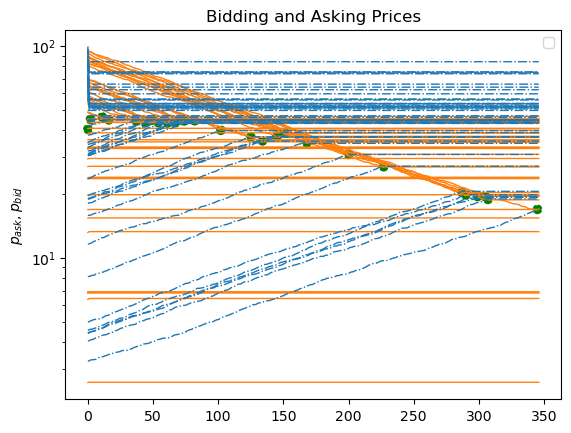

In [28]:
lw = 1

plt.plot(asking_prices, ls='-', c='C1', lw=lw)

plt.plot(bidding_prices, ls='-.', c='C0', lw=lw)

plt.scatter(range(len(trial_price)), trial_price, c='green', ls='--')

plt.ylabel('$p_{ask}, p_{bid}$')
plt.title('Bidding and Asking Prices')
plt.legend()

plt.yscale('log')

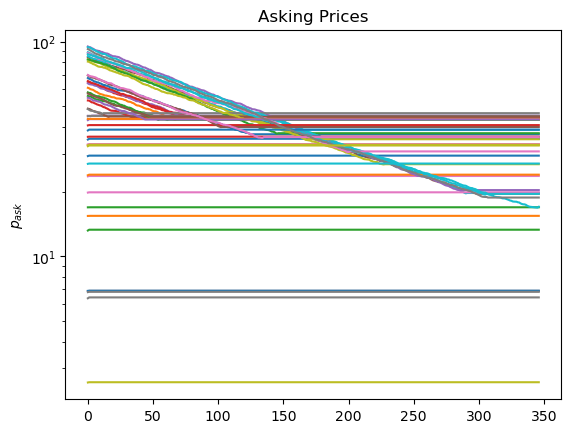

In [29]:
plt.plot(asking_prices, ls='-')#, c='C1', lw=0.1)
plt.ylabel('$p_{ask}$')
plt.title('Asking Prices')
plt.yscale('log')

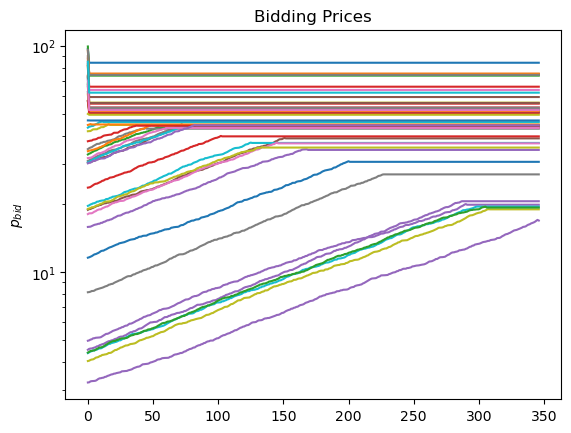

In [30]:
plt.plot(bidding_prices, ls='-')#, c='C0', lw=0.1)
plt.ylabel('$p_{bid}$')
plt.title('Bidding Prices')
plt.yscale('log')

Text(0, 0.5, '$S^{\\sigma}$')

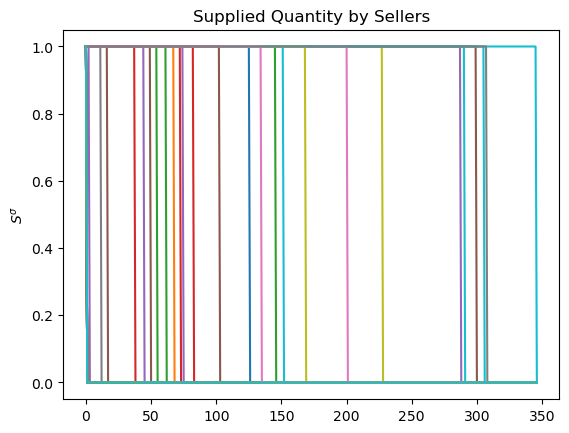

In [31]:
plt.plot(supply)#, c='C1')
#plt.scatter(x=range(len(seller_supply)), y=seller_supply, c='C1')

plt.title('Supplied Quantity by Sellers')
plt.ylabel('$S^{\sigma}$')
#plt.yscale('log')

Text(0, 0.5, '$-S^{\\beta}$')

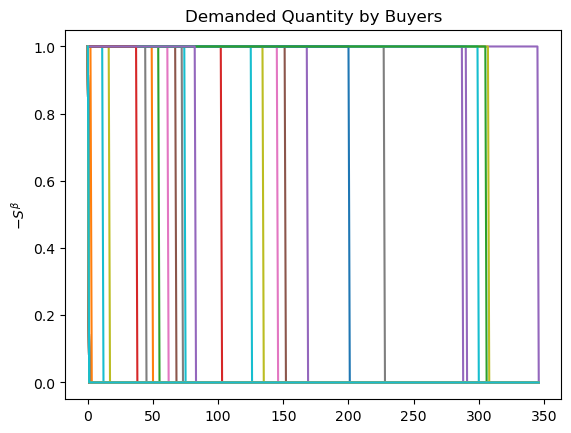

In [32]:
plt.plot(demand)#, c='C0')
#plt.scatter(x=range(len(buyer_demand)), y=buyer_demand, c='C0')

plt.title('Demanded Quantity by Buyers')
plt.ylabel(r'$-S^{\beta}$')

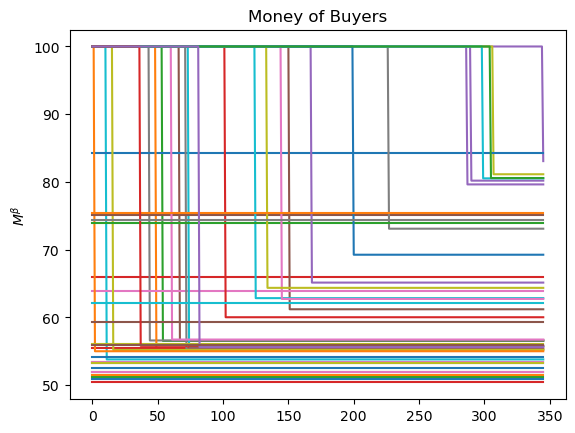

In [33]:
plt.plot(buyer_money)#, c='C0')
#plt.plot(bidding_prices, ls=':')
#plt.plot(buyer_money2, c='g', ls=':')
plt.title('Money of Buyers')
plt.ylabel(r'$M^{\beta}$')
plt.show()

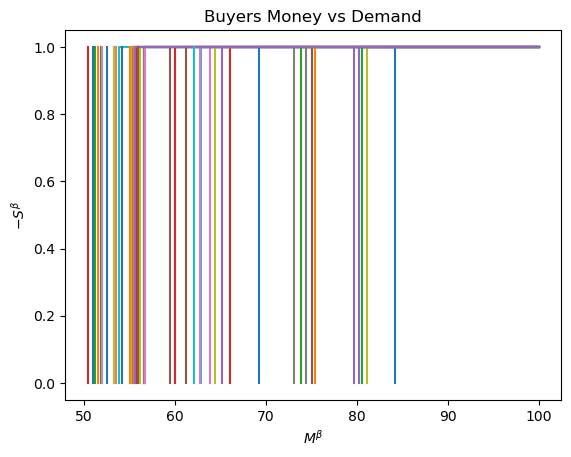

In [34]:
plt.plot(buyer_money, demand[:-1])#, c='C0')
#plt.plot(buyer_money2, c='g', ls=':')
plt.title('Buyers Money vs Demand')
plt.xlabel(r'$M^{\beta}$')
plt.ylabel(r'$-S^{\beta}$')
plt.show()

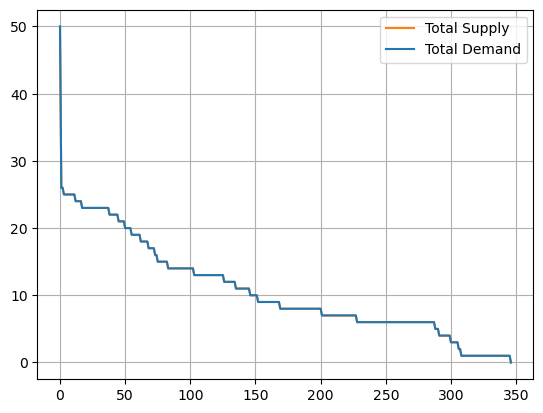

In [35]:
plt.plot(supply.sum(axis=1), c='C1', label='Total Supply')
plt.plot(demand.sum(axis=1), c='C0', label='Total Demand')
plt.legend()
#plt.yscale('log')
plt.grid()

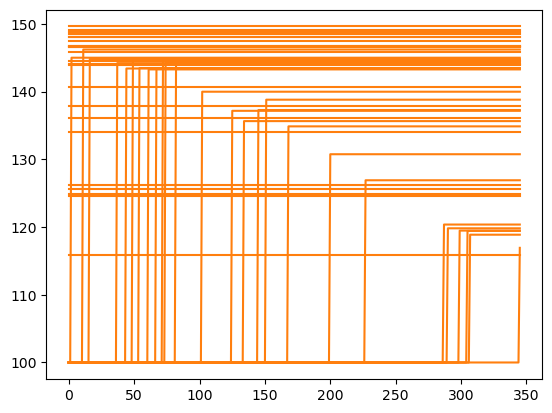

In [36]:
plt.plot(seller_money, c='C1')
plt.show()

Text(0, 0.5, 'Mean Asking Price')

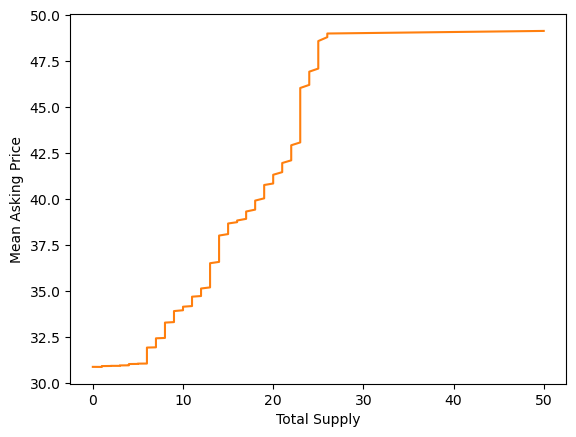

In [37]:
plt.plot(total_supply, mean_asks , c='C1')
plt.xlabel('Total Supply')
plt.ylabel('Mean Asking Price')

Text(0, 0.5, 'Mean Bidding Price')

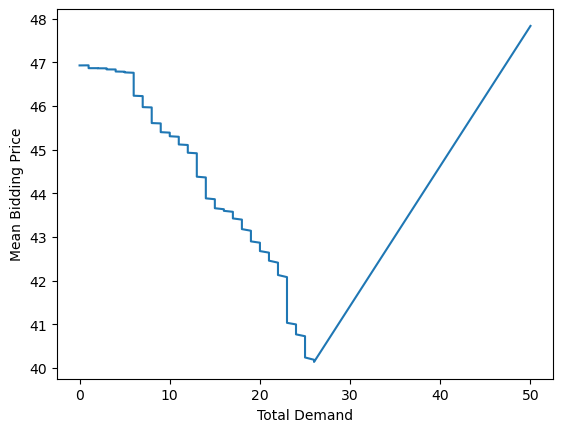

In [38]:
plt.plot(total_demand, mean_bids, c='C0')
plt.xlabel('Total Demand')
plt.ylabel('Mean Bidding Price')

In [39]:
#[plt.plot(buyer_money[:,n], buyer_money2[:-1,n]) for n in range(NB)]
#plt.show()

In [40]:
#buyer_money[:,n], buyer_money2[:-1,n]

Text(0, 0.5, '$p_{ask}$')

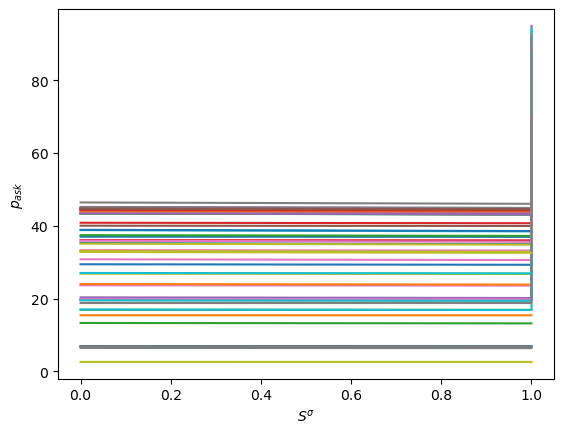

In [41]:
plt.plot(supply, asking_prices)#, c='C1')
plt.xlabel('$S^{\sigma}$')
plt.ylabel('$p_{ask}$')

Text(0, 0.5, '$p_{bid}$')

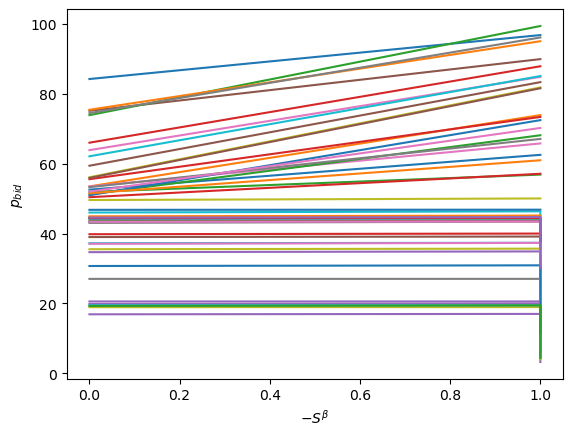

In [42]:
plt.plot(demand, bidding_prices)#, c='C0')
plt.xlabel(r'$-S^{\beta}$')
plt.ylabel('$p_{bid}$')
#plt.xscale('log')
#plt.yscale('log')

Text(0, 0.5, '$p_{bid}$')

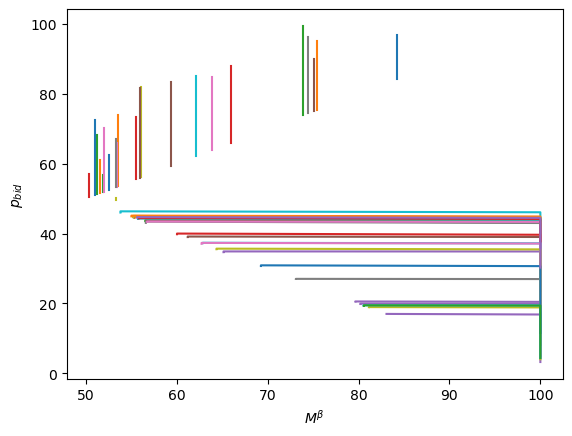

In [43]:
plt.plot(buyer_money, bidding_prices[:-1])#, c='C0')
plt.xlabel(r'$M^{\beta}$')
plt.ylabel('$p_{bid}$')
#plt.xscale('log')
#plt.yscale('log')

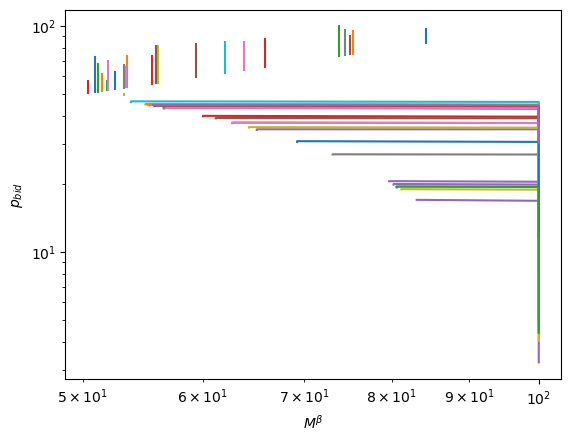

In [44]:
plt.plot(buyer_money, bidding_prices[:-1])#, c='C0')
plt.xlabel(r'$M^{\beta}$')
plt.ylabel('$p_{bid}$')
plt.xscale('log')
plt.yscale('log')

In [45]:
buyer_money.shape, bidding_prices.shape

((346, 50), (347, 50))

In [46]:
assert False

AssertionError: 

In [ ]:
for agent in agent_list:
    
    print(agent.Q)

In [ ]:
for agent in agent_list:
    
    print(agent.p_buy)

In [ ]:
agent_data

In [ ]:
agent_Mdata